In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

<Axes: >

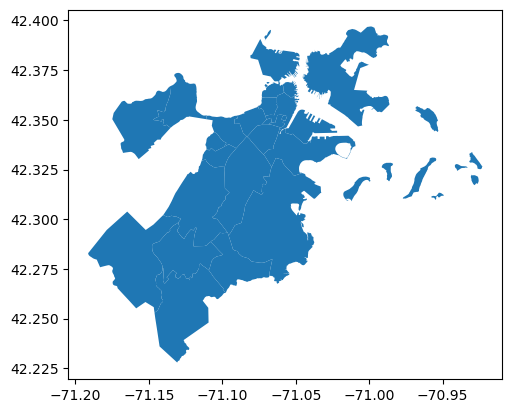

In [2]:
gdf = gpd.read_file('C:/Users/karna/Documents/Berkeley/Year 2/Human Mobility and Network Science/Assignments/Final Project.Parkximity/Parkximity/Data/Raw/Boston/boston_neighborhood_boundaries.geojson.json')
gdf.plot()

In [3]:
gdf

,OBJECTID,name,acres,neighborhood_id,sqmiles,Shape_Length,Shape_Area,shape_wkt,geometry
0,1,Roslindale,1605.568237,15,2.51,0.169120,0.000709,None,"MULTIPOLYGON (((-71.126 42.272, -71.126 42.272..."
1,2,Jamaica Plain,2519.245394,11,3.94,0.179578,0.001113,None,"POLYGON ((-71.105 42.326, -71.105 42.326, -71...."
2,3,Mission Hill,350.853564,13,0.55,0.059235,0.000155,None,"POLYGON ((-71.09 42.336, -71.091 42.336, -71.0..."
3,4,Longwood,188.611947,28,0.29,0.038816,0.000083,None,"POLYGON ((-71.098 42.337, -71.098 42.337, -71...."
4,5,Bay Village,26.539839,33,0.04,0.015625,0.000012,None,"POLYGON ((-71.067 42.349, -71.067 42.349, -71...."
5,6,Leather District,15.639908,27,0.02,0.010478,0.000007,None,"POLYGON ((-71.058 42.35, -71.058 42.35, -71.05..."
6,7,Chinatown,76.324410,26,0.12,0.032741,0.000034,None,"POLYGON ((-71.058 42.352, -71.058 42.352, -71...."
7,8,North End,126.910439,14,0.20,0.052807,0.000056,None,"POLYGON ((-71.052 42.369, -71.052 42.369, -71...."
8,9,Roxbury,2108.469072,16,3.29,0.153269,0.000932,None,"POLYGON ((-71.096 42.293, -71.096 42.293, -71...."
9,10,South End,471.535356,32,0.74,0.058465,0.000208,None,"POLYGON ((-71.068 42.348, -71.069 42.348, -71...."


In [5]:
gdf1 = gpd.read_file('C:/Users/karna/Documents/Berkeley/Year 2/Human Mobility and Network Science/Assignments/Final Project.Parkximity/Parkximity/Data/Processed/lts_bos.geojson')
gdf1

Skipping field name: unsupported OGR type: 5


,u,v,key,osmid,highway,maxspeed,lanes,bikeway_rank,PC1,PC2,PC1_norm,PC2_norm,geometry
0,30730954,61441677,0,197230699,residential,25.0,2.0,NaN,-0.069993,-0.415363,0.333481,0.444617,"LINESTRING (-71.022 42.368, -71.022 42.368, -7..."
1,30730954,1102741801,0,"[ 1428253927, 1428253928, 1428253929, 14282539...",residential,25.0,2.0,NaN,-0.069993,-0.415363,0.333481,0.444617,"LINESTRING (-71.022 42.368, -71.022 42.368, -7..."
2,61178875,61451303,0,8649976,residential,25.0,2.0,NaN,-0.069993,-0.415363,0.333481,0.444617,"LINESTRING (-71.081 42.382, -71.081 42.382, -7..."
3,61178875,61356798,0,"[ 426653648, 1196171461, 8651189, 1086801839 ]",primary,25.0,2.0,5.0,0.917758,2.052496,0.383738,0.708350,"LINESTRING (-71.081 42.382, -71.081 42.382, -7..."
4,61339242,4939210774,0,"[ 93125345, 503649029 ]",tertiary,25.0,2.0,NaN,-0.069993,-0.415363,0.333481,0.444617,"LINESTRING (-71.06 42.319, -71.06 42.319, -71...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28650,13325546417,61379394,0,"[ 43119204, 1226254417, 8642466, 8644060 ]",motorway,45.0,2.0,NaN,5.358941,-2.079857,0.609704,0.266737,"LINESTRING (-71.03 42.375, -71.03 42.375, -71...."
28651,13325546417,61350276,0,"[ 178910661, 1453014197 ]",motorway_link,30.0,2.0,NaN,1.287240,-0.831487,0.402537,0.400147,"LINESTRING (-71.03 42.375, -71.03 42.375, -71...."
28652,13325581910,8686265169,0,196377008,motorway,45.0,4.0,NaN,7.609645,-3.189006,0.724220,0.148206,"LINESTRING (-71.027 42.378, -71.028 42.377)"
28653,13326891542,61353536,0,521568356,residential,25.0,2.0,NaN,-0.069993,-0.415363,0.333481,0.444617,"LINESTRING (-71.14 42.25, -71.14 42.25, -71.14..."


In [21]:
gdf2 = gpd.read_file('C:/Users/karna/Documents/Berkeley/Year 2/Human Mobility and Network Science/Assignments/Final Project.Parkximity/Parkximity/Data/Raw/Boston/Parcels__2024_.geojson')
gdf2.plot()

GEOSException: IllegalArgumentException: Invalid number of points in LinearRing found 3 - must be 0 or >= 4

In [19]:
#!/usr/bin/env python3
"""
Export parks in Boston, MA as GeoJSON from OpenStreetMap data.
Simple version with no command-line arguments - just run it!

Usage as script:
    python boston_parks_export.py
    
Usage in notebook:
    from boston_parks_export import export_boston_parks
    geojson = export_boston_parks("my_output_directory")
"""

import requests
import json
import os
from typing import Dict, Any


def query_overpass_api(query: str) -> Dict[str, Any]:
    """
    Query the Overpass API and return the JSON response.
    
    Args:
        query: Overpass QL query string
        
    Returns:
        Dictionary containing the API response
    """
    overpass_url = "https://overpass-api.de/api/interpreter"
    response = requests.post(overpass_url, data={"data": query})
    response.raise_for_status()
    return response.json()


def convert_to_geojson(osm_data: Dict[str, Any]) -> Dict[str, Any]:
    """
    Convert OSM data to GeoJSON format.
    
    Args:
        osm_data: Raw OSM data from Overpass API
        
    Returns:
        GeoJSON FeatureCollection
    """
    features = []
    skipped = 0
    
    for element in osm_data.get("elements", []):
        # Extract properties (tags)
        properties = element.get("tags", {})
        properties["osm_id"] = element.get("id")
        properties["osm_type"] = element.get("type")
        
        # Handle ways with geometry
        if element.get("type") == "way" and "geometry" in element and element["geometry"]:
            coordinates = [[node["lon"], node["lat"]] for node in element["geometry"]]
            
            # Validate coordinates
            if len(coordinates) < 3:
                skipped += 1
                continue
            
            # Check for valid coordinate values
            if not all(isinstance(c[0], (int, float)) and isinstance(c[1], (int, float)) 
                      for c in coordinates):
                skipped += 1
                continue
            
            # Check for NaN or infinite values
            if any(c[0] != c[0] or c[1] != c[1] or 
                   abs(c[0]) == float('inf') or abs(c[1]) == float('inf') 
                   for c in coordinates):
                skipped += 1
                continue
            
            # Close the polygon if it's not already closed
            if coordinates[0] != coordinates[-1]:
                coordinates.append(coordinates[0])
            
            # Additional validation: ensure we have at least 4 points (3 unique + closing point)
            if len(coordinates) < 4:
                skipped += 1
                continue
            
            feature = {
                "type": "Feature",
                "properties": properties,
                "geometry": {
                    "type": "Polygon",
                    "coordinates": [coordinates]
                }
            }
            features.append(feature)
        
        # Handle relations (multipolygons)
        elif element.get("type") == "relation" and "members" in element:
            # For relations, we need to process members
            outer_ways = []
            
            for member in element.get("members", []):
                if member.get("role") == "outer" and "geometry" in member:
                    coords = [[node["lon"], node["lat"]] for node in member["geometry"]]
                    if len(coords) >= 3:
                        # Close if needed
                        if coords[0] != coords[-1]:
                            coords.append(coords[0])
                        if len(coords) >= 4:
                            outer_ways.append(coords)
            
            # Create polygon or multipolygon based on number of outer ways
            if len(outer_ways) == 1:
                feature = {
                    "type": "Feature",
                    "properties": properties,
                    "geometry": {
                        "type": "Polygon",
                        "coordinates": outer_ways
                    }
                }
                features.append(feature)
            elif len(outer_ways) > 1:
                feature = {
                    "type": "Feature",
                    "properties": properties,
                    "geometry": {
                        "type": "MultiPolygon",
                        "coordinates": [[way] for way in outer_ways]
                    }
                }
                features.append(feature)
    
    if skipped > 0:
        print(f"Skipped {skipped} invalid geometries")
    
    return {
        "type": "FeatureCollection",
        "features": features
    }


def get_boston_parks() -> Dict[str, Any]:
    """
    Query OpenStreetMap for parks in Boston, MA and return as GeoJSON.
    
    Returns:
        GeoJSON FeatureCollection of Boston parks
    """
    # Bounding box for Boston, MA (south, west, north, east)
    bbox = "42.2279,-71.1912,42.3969,-70.9231"
    
    # Overpass QL query for parks in Boston using bounding box
    overpass_query = f"""
    [out:json][timeout:60];
    (
      way["leisure"="park"]({bbox});
      way["leisure"="playground"]({bbox});
      way["leisure"="recreation_ground"]({bbox});
      way["leisure"="garden"]({bbox});
      way["leisure"="nature_reserve"]({bbox});
      way["boundary"="national_park"]({bbox});
      relation["leisure"="park"]({bbox});
      relation["leisure"="playground"]({bbox});
      relation["leisure"="recreation_ground"]({bbox});
      relation["leisure"="garden"]({bbox});
      relation["leisure"="nature_reserve"]({bbox});
      relation["boundary"="national_park"]({bbox});
    );
    out geom;
    """
    
    print("Querying OpenStreetMap for Boston parks...")
    print(f"Using bounding box: {bbox}")
    osm_data = query_overpass_api(overpass_query)
    
    print(f"Found {len(osm_data.get('elements', []))} park elements")
    
    print("Converting to GeoJSON...")
    geojson = convert_to_geojson(osm_data)
    
    return geojson


def save_geojson(geojson: Dict[str, Any], output_dir: str = "."):
    """
    Save GeoJSON data to a file in the specified directory.
    
    Args:
        geojson: GeoJSON data to save
        output_dir: Directory to save the file in
    """
    # Validate GeoJSON before saving
    if not geojson.get("features"):
        print("Warning: No features to save!")
        return None
    
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Full path for output file
    output_path = os.path.join(output_dir, "boston_parks.geojson")
    
    with open(output_path, 'w', encoding='utf-8') as f:
        json.dump(geojson, f, indent=2, ensure_ascii=False)
    
    print(f"Saved to {output_path}")
    
    # Print bounds for debugging
    all_lons = []
    all_lats = []
    for feature in geojson["features"]:
        if feature["geometry"]["type"] == "Polygon":
            coords = feature["geometry"]["coordinates"][0]
            all_lons.extend([c[0] for c in coords])
            all_lats.extend([c[1] for c in coords])
        elif feature["geometry"]["type"] == "MultiPolygon":
            for polygon in feature["geometry"]["coordinates"]:
                coords = polygon[0]
                all_lons.extend([c[0] for c in coords])
                all_lats.extend([c[1] for c in coords])
    
    if all_lons and all_lats:
        print(f"Bounds: lon=[{min(all_lons):.6f}, {max(all_lons):.6f}], lat=[{min(all_lats):.6f}, {max(all_lats):.6f}]")
    
    return output_path


def export_boston_parks(output_dir: str = ".") -> Dict[str, Any]:
    """
    Main function to export Boston parks. Can be called from scripts or notebooks.
    
    Args:
        output_dir: Directory to save the GeoJSON file (default: current directory)
        
    Returns:
        GeoJSON FeatureCollection of Boston parks
    """
    try:
        # Get parks data
        geojson = get_boston_parks()
        
        # Save to file
        output_path = save_geojson(geojson, output_dir)
        
        # Print summary
        print(f"/nExport complete!")
        print(f"Total parks exported: {len(geojson['features'])}")
        
        # Show sample of park names
        if geojson['features']:
            park_names = [f.get("properties", {}).get("name", "Unnamed") 
                         for f in geojson["features"][:10]]
            print(f"Sample parks: {', '.join(park_names)}")
        
        return geojson
        
    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        raise


if __name__ == "__main__":
    # When run as a script, save to current directory
    export_boston_parks("C:/Users/karna/Documents/Berkeley/Year 2/Human Mobility and Network Science/Assignments/Final Project.Parkximity/Parkximity/Data/Raw/Boston")

Querying OpenStreetMap for Boston parks...
Using bounding box: 42.2279,-71.1912,42.3969,-70.9231
Found 1930 park elements
Converting to GeoJSON...
Saved to C:/Users/karna/Documents/Berkeley/Year 2/Human Mobility and Network Science/Assignments/Final Project.Parkximity/Parkximity/Data/Raw/Boston\boston_parks.geojson
Bounds: lon=[-71.215355, -70.903348], lat=[42.159315, 42.403364]
/nExport complete!
Total parks exported: 1929
Sample parks: Polcari Park, Cutillo Park, Cambridge Common, Boston Public Garden, Elm-Hampshire Park, Ronan Park, Unnamed, Judge Summer Z. Kaplan Park, Briggs Field, Mother's Rest


<Axes: >

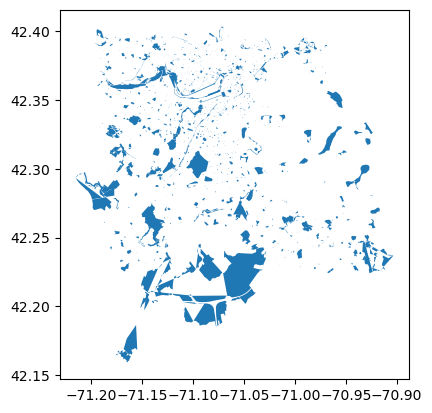

In [20]:
gdf3 = gpd.read_file('C:/Users/karna/Documents/Berkeley/Year 2/Human Mobility and Network Science/Assignments/Final Project.Parkximity/Parkximity/Data/Raw/Boston/boston_parks.geojson')
gdf3.plot()